# Concrete Compressive Strength — Dataset Analysis

**Source:** UCI ML Repository #165 — 1030 observations, 8 mix-design predictors, 1 MPa strength target.

- **Block 1** — Summary statistics and targeted visualisations to characterise the dataset.
- **Block 2** — Preprocessing pipeline: quality checks, feature engineering, train/test split, and artifacts saved for ZZU and baseline methods.

Dataset : 1030 rows x 9 columns
Missing : 0
Duplicates: 25

        cement  blast_furnace_slag  fly_ash    water  superplasticizer  coarse_aggregate  fine_aggregate      age  compressive_strength
count  1030.00             1030.00  1030.00  1030.00           1030.00           1030.00         1030.00  1030.00               1030.00
mean    281.17               73.90    54.19   181.57              6.20            972.92          773.58    45.66                 35.82
std     104.51               86.28    64.00    21.36              5.97             77.75           80.18    63.17                 16.71
min     102.00                0.00     0.00   121.75              0.00            801.00          594.00     1.00                  2.33
25%     192.38                0.00     0.00   164.90              0.00            932.00          730.95     7.00                 23.71
50%     272.90               22.00     0.00   185.00              6.35            968.00          779.51    28.00           

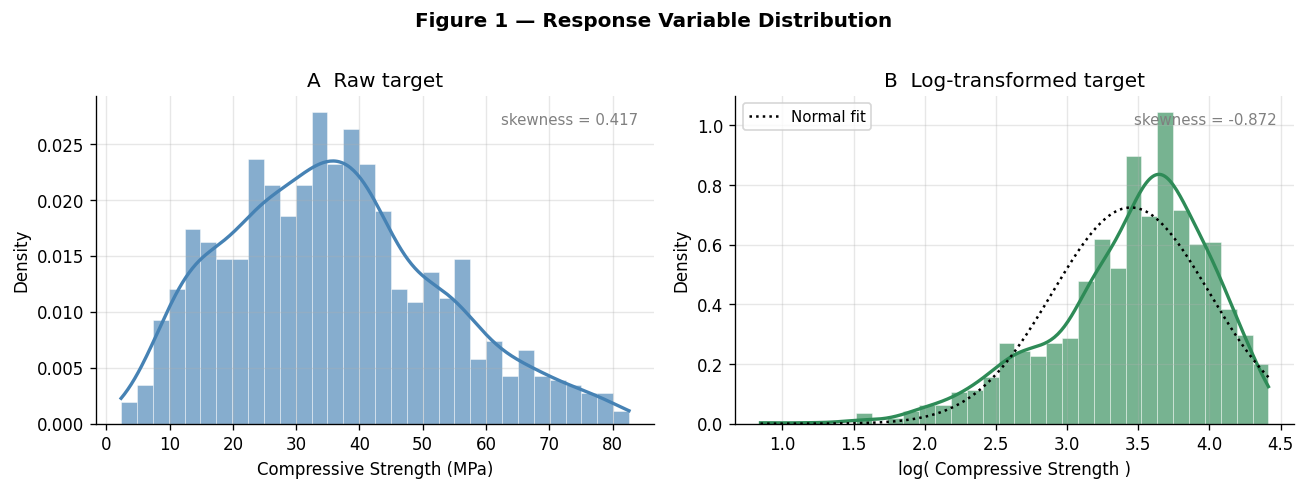

Strength range : 2.3 to 82.6 MPa  (35x ratio)
Skewness       : raw = 0.417,  log-transformed = -0.872
-> Log transform substantially reduces skew but does not fully normalise.
   Box-Cox/Yeo-Johnson will be screened by ZZU for a better lambda.


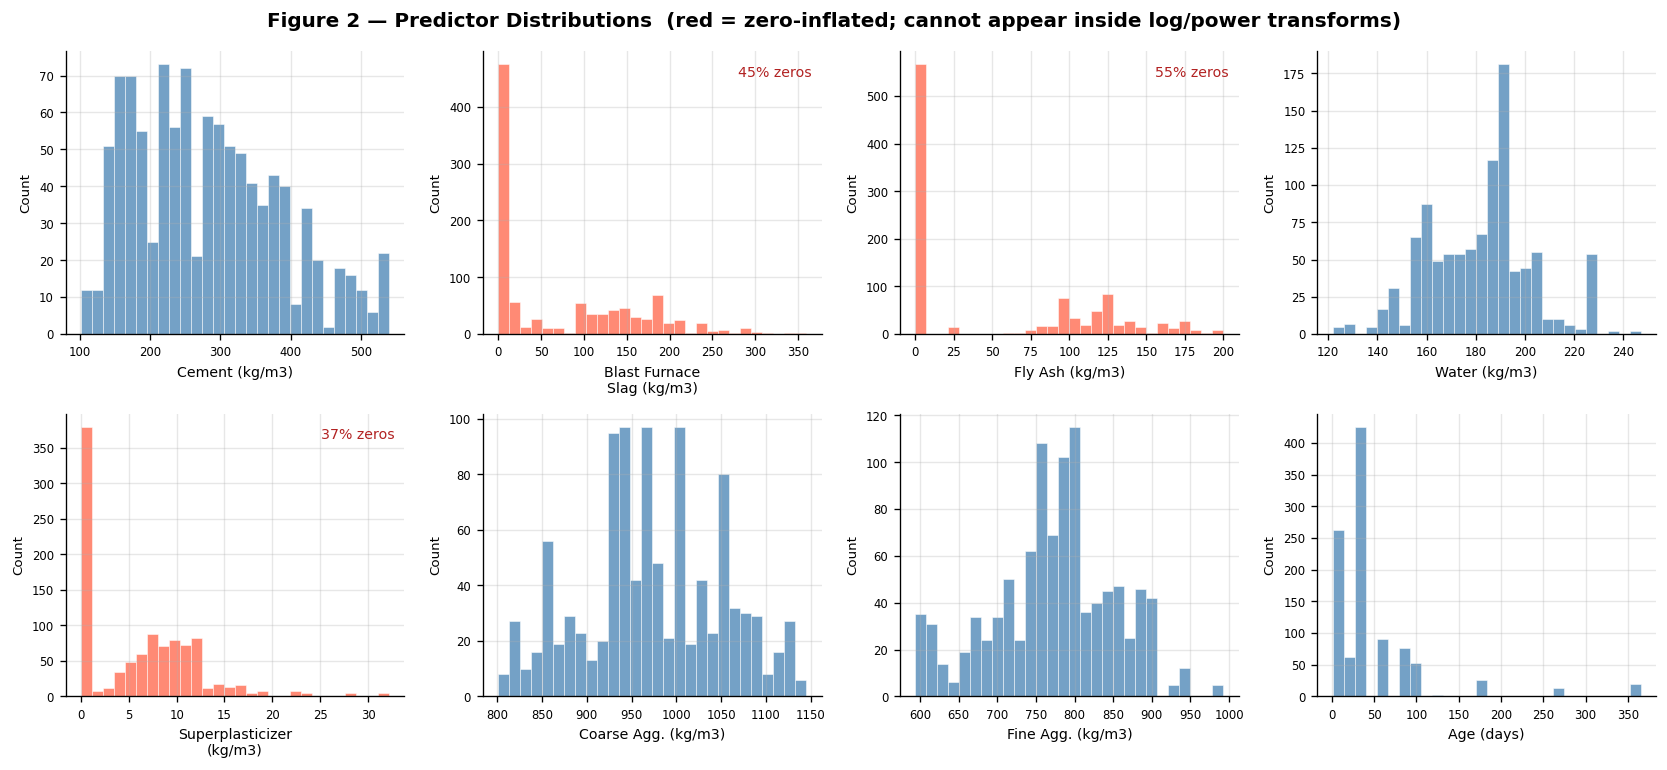

Zero-inflated features: slag, fly_ash, superplasticizer.
These will enter the ZZU model_fn as additive supplement terms, not inside power laws.


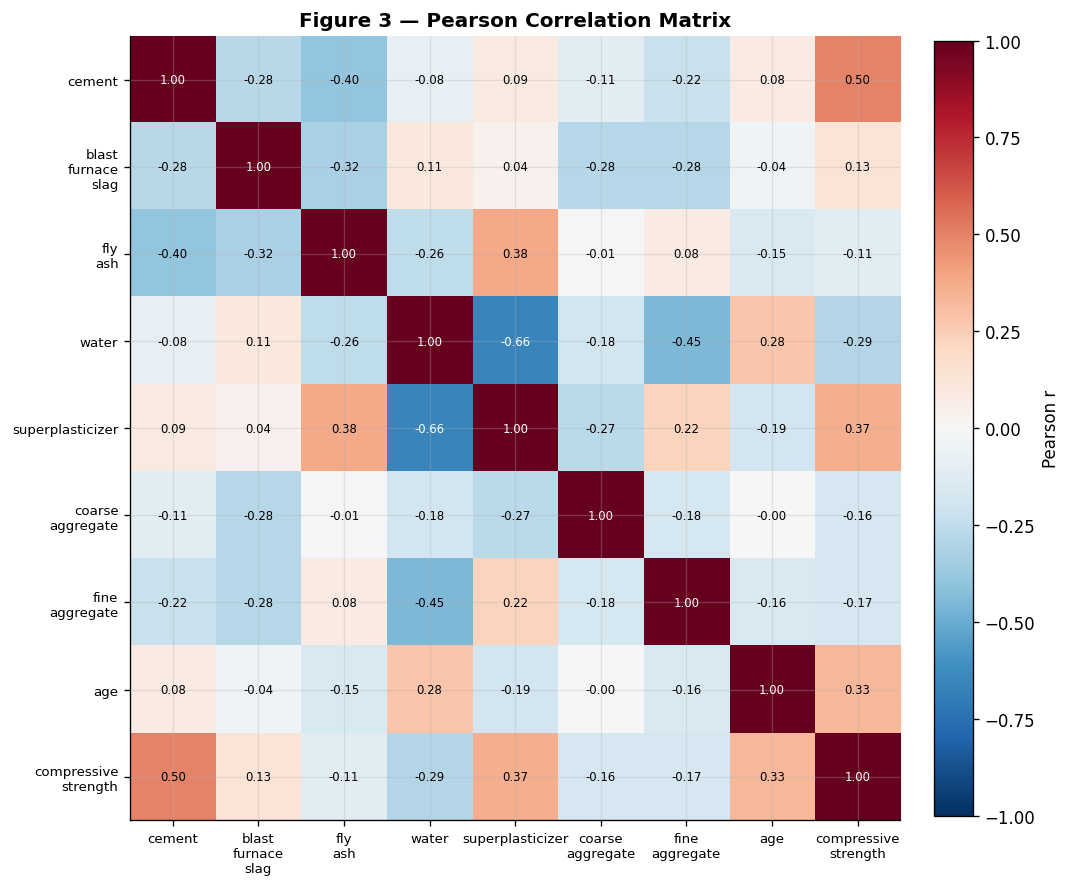

Correlation with compressive strength (ranked):
  cement                   +0.498  |||||||||
  superplasticizer         +0.366  |||||||
  age                      +0.329  ||||||
  water                    -0.290  |||||
  fine_aggregate           -0.167  |||
  coarse_aggregate         -0.165  |||
  blast_furnace_slag       +0.135  ||
  fly_ash                  -0.106  ||


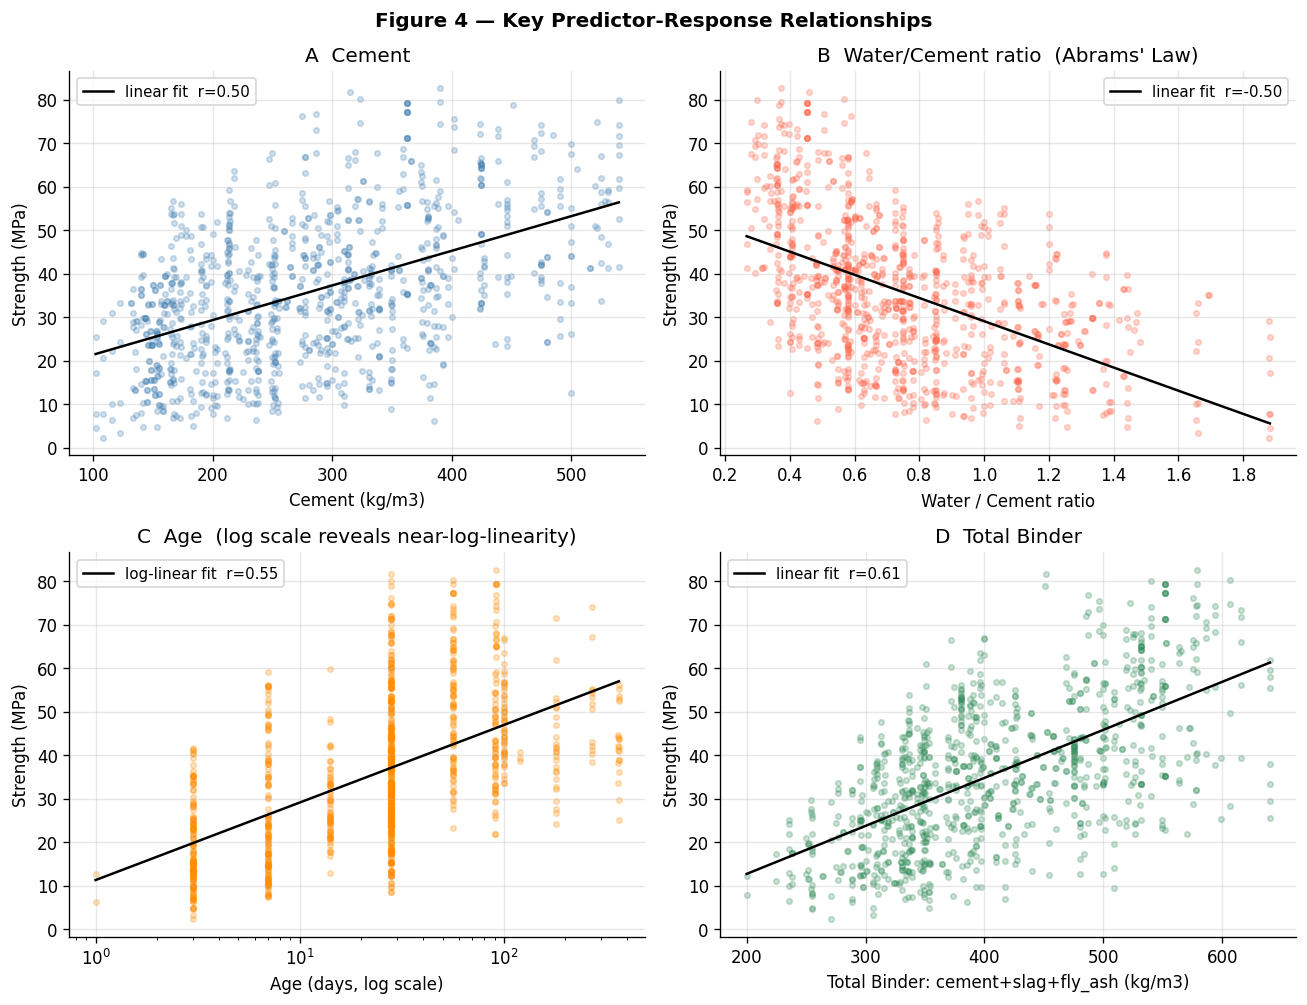

Takeaways for model_fn design:
  1. Cement and total binder have a positive, near-linear relationship with strength.
  2. Water/cement ratio is the dominant driver (Abrams Law, 1919).
  3. Age is log-linear on a log scale -> a power-law term age^theta is appropriate.
  4. No single linear transformation captures all three simultaneously -> ZZU territory.


In [3]:
# ================================================================
# BLOCK 1 — Dataset Exploration
# ================================================================
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

df = pd.read_csv('concrete.csv')

FEATURES = [
    'cement', 'blast_furnace_slag', 'fly_ash', 'water',
    'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age'
]
TARGET = 'compressive_strength'
y = df[TARGET].values

# ---- printed summary ----
print(f'Dataset : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Missing : {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')
print()
print(df.describe().round(2).to_string())
print()
zero_pct = {c: (df[c] == 0).mean() * 100 for c in FEATURES}
print('Zero-valued entries per predictor:')
for c, p in zero_pct.items():
    bar = '|' * int(p / 2)
    tag = '  <- zero-inflated (breaks log/power transforms)' if p > 10 else ''
    print(f'  {c:<24} {p:5.1f}%  {bar}{tag}')

# ---- KDE helper (Silverman bandwidth, vectorised) ----
def kde(data, xg, bw=None):
    d = np.asarray(data, float)
    if bw is None:
        bw = 1.06 * d.std() * len(d) ** (-0.2)
    u = (xg[:, None] - d[None, :]) / bw
    return np.mean(np.exp(-0.5 * u ** 2), axis=1) / (bw * np.sqrt(2 * np.pi))

# ================================================================
# Figure 1 — Response variable distribution
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, xlabel, color, title in [
    (axes[0], y,          'Compressive Strength (MPa)', 'steelblue', 'A  Raw target'),
    (axes[1], np.log(y),  'log( Compressive Strength )', 'seagreen',  'B  Log-transformed target'),
]:
    ax.hist(data, bins=32, density=True, color=color, alpha=0.65,
            edgecolor='white', linewidth=0.4)
    xg = np.linspace(data.min(), data.max(), 300)
    ax.plot(xg, kde(data, xg), color=color, lw=2)
    if color == 'seagreen':
        mu, sigma = data.mean(), data.std()
        ax.plot(xg, np.exp(-0.5 * ((xg - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
                'k:', lw=1.5, label='Normal fit')
        ax.legend(fontsize=9)
    sk = float(pd.Series(data).skew())
    ax.text(0.97, 0.95, f'skewness = {sk:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title)

fig.suptitle('Figure 1 — Response Variable Distribution', fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

print(f'Strength range : {y.min():.1f} to {y.max():.1f} MPa  ({y.max()/y.min():.0f}x ratio)')
print(f'Skewness       : raw = {float(pd.Series(y).skew()):.3f},  '
      f'log-transformed = {float(pd.Series(np.log(y)).skew()):.3f}')
print('-> Log transform substantially reduces skew but does not fully normalise.')
print('   Box-Cox/Yeo-Johnson will be screened by ZZU for a better lambda.')

# ================================================================
# Figure 2 — Feature distributions (zero-inflation visible)
# ================================================================
FEAT_LABELS = [
    'Cement (kg/m3)', 'Blast Furnace\nSlag (kg/m3)', 'Fly Ash (kg/m3)',
    'Water (kg/m3)', 'Superplasticizer\n(kg/m3)', 'Coarse Agg. (kg/m3)',
    'Fine Agg. (kg/m3)', 'Age (days)'
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for ax, col, label in zip(axes.flat, FEATURES, FEAT_LABELS):
    data = df[col].values
    pct_z = (data == 0).mean() * 100
    color = 'tomato' if pct_z > 10 else 'steelblue'
    ax.hist(data, bins=28, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    if pct_z > 0:
        ax.text(0.97, 0.95, f'{pct_z:.0f}% zeros', transform=ax.transAxes,
                ha='right', va='top', fontsize=8.5,
                color='firebrick' if pct_z > 10 else 'dimgray')
    ax.set_xlabel(label, fontsize=8.5)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(
    'Figure 2 — Predictor Distributions  '
    '(red = zero-inflated; cannot appear inside log/power transforms)',
    fontweight='bold'
)
fig.tight_layout()
plt.show()

print('Zero-inflated features: slag, fly_ash, superplasticizer.')
print('These will enter the ZZU model_fn as additive supplement terms, not inside power laws.')

# ================================================================
# Figure 3 — Pearson correlation matrix
# ================================================================
fig, ax = plt.subplots(figsize=(9, 7.5))
corr = df.corr()
labels = [c.replace('_', '\n') for c in corr.columns]
n = len(labels)
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(n):
    for j in range(n):
        v = corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(v) > 0.55 else 'black')
ax.set_title('Figure 3 — Pearson Correlation Matrix', fontweight='bold', fontsize=12)
fig.tight_layout()
plt.show()

tgt_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('Correlation with compressive strength (ranked):')
for feat, val in tgt_corr.items():
    bar = '|' * int(abs(val) * 20)
    print(f'  {feat:<24} {val:+.3f}  {bar}')

# ================================================================
# Figure 4 — Key predictor-response relationships
# ================================================================
wc = df['water'].values / df['cement'].values
binder = df['cement'].values + df['blast_furnace_slag'].values + df['fly_ash'].values

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))

# (0,0) Cement vs strength
ax = axes[0, 0]
ax.scatter(df['cement'].values, y, alpha=0.25, s=11, color='steelblue', rasterized=True)
cx = df['cement'].values
cf = np.polyfit(cx, y, 1)
xf = np.linspace(cx.min(), cx.max(), 200)
ax.plot(xf, np.polyval(cf, xf), 'k-', lw=1.5,
        label=f'linear fit  r={np.corrcoef(cx, y)[0,1]:.2f}')
ax.set_xlabel('Cement (kg/m3)')
ax.set_ylabel('Strength (MPa)')
ax.set_title('A  Cement')
ax.legend(fontsize=9)

# (0,1) Water/cement ratio vs strength
ax = axes[0, 1]
ax.scatter(wc, y, alpha=0.25, s=11, color='tomato', rasterized=True)
wf = np.polyfit(wc, y, 1)
xf = np.linspace(wc.min(), wc.max(), 200)
ax.plot(xf, np.polyval(wf, xf), 'k-', lw=1.5,
        label=f'linear fit  r={np.corrcoef(wc, y)[0,1]:.2f}')
ax.set_xlabel('Water / Cement ratio')
ax.set_ylabel('Strength (MPa)')
ax.set_title("B  Water/Cement ratio  (Abrams' Law)")
ax.legend(fontsize=9)

# (1,0) Age vs strength — log x-scale to reveal power-law
ax = axes[1, 0]
ages = df['age'].values
ax.scatter(ages, y, alpha=0.25, s=11, color='darkorange', rasterized=True)
ax.set_xscale('log')
log_ages = np.log(ages)
af = np.polyfit(log_ages, y, 1)
xf_log = np.logspace(np.log10(ages.min()), np.log10(ages.max()), 200)
ax.plot(xf_log, af[0] * np.log(xf_log) + af[1], 'k-', lw=1.5,
        label=f'log-linear fit  r={np.corrcoef(log_ages, y)[0,1]:.2f}')
ax.set_xlabel('Age (days, log scale)')
ax.set_ylabel('Strength (MPa)')
ax.set_title('C  Age  (log scale reveals near-log-linearity)')
ax.legend(fontsize=9)

# (1,1) Total binder vs strength
ax = axes[1, 1]
ax.scatter(binder, y, alpha=0.25, s=11, color='seagreen', rasterized=True)
bf = np.polyfit(binder, y, 1)
xf = np.linspace(binder.min(), binder.max(), 200)
ax.plot(xf, np.polyval(bf, xf), 'k-', lw=1.5,
        label=f'linear fit  r={np.corrcoef(binder, y)[0,1]:.2f}')
ax.set_xlabel('Total Binder: cement+slag+fly_ash (kg/m3)')
ax.set_ylabel('Strength (MPa)')
ax.set_title('D  Total Binder')
ax.legend(fontsize=9)

fig.suptitle('Figure 4 — Key Predictor-Response Relationships', fontweight='bold')
fig.tight_layout()
plt.show()

print('Takeaways for model_fn design:')
print('  1. Cement and total binder have a positive, near-linear relationship with strength.')
print('  2. Water/cement ratio is the dominant driver (Abrams Law, 1919).')
print('  3. Age is log-linear on a log scale -> a power-law term age^theta is appropriate.')
print('  4. No single linear transformation captures all three simultaneously -> ZZU territory.')

---
## Block 2 — Preprocessing

Goals:
1. Audit data quality and catalog zero-inflated features.
2. Engineer domain-motivated features (`wc_ratio`, `binder`).
3. Define the final feature set with explicit rationale.
4. Produce a reproducible 80/20 train/test split.
5. Build the column-index map (`COL`) required by `model_fn`.
6. Save all artifacts to `concrete_split.npz` for the analysis notebook.

[1] Quality verification
  Rows            : 1030
  Missing values  : 0
  Duplicate rows  : 25  (same mix design, independent pours — retained)

[2] Outlier audit  (3 x IQR, flag but retain — these are real lab measurements)
  age                     : 33 extreme value(s)
  Rows with >= 1 extreme value: 33 / 1030

[3] Zero-inflation catalog
  cement                  :     0 zeros  -> log-safe
  blast_furnace_slag      : 466 zeros  (45.2%)  -> zero-inflated, additive only
  fly_ash                 : 566 zeros  (55.0%)  -> zero-inflated, additive only
  water                   :     0 zeros  -> log-safe
  superplasticizer        : 379 zeros  (36.8%)  -> zero-inflated, additive only
  coarse_aggregate        :     0 zeros  -> log-safe
  fine_aggregate          :     0 zeros  -> log-safe
  age                     :     0 zeros  -> log-safe

  LOG_SAFE      = ['cement', 'water', 'coarse_aggregate', 'fine_aggregate', 'age']
  ZERO_INFLATED = ['blast_furnace_slag', 'fly_ash', 'superplasticize

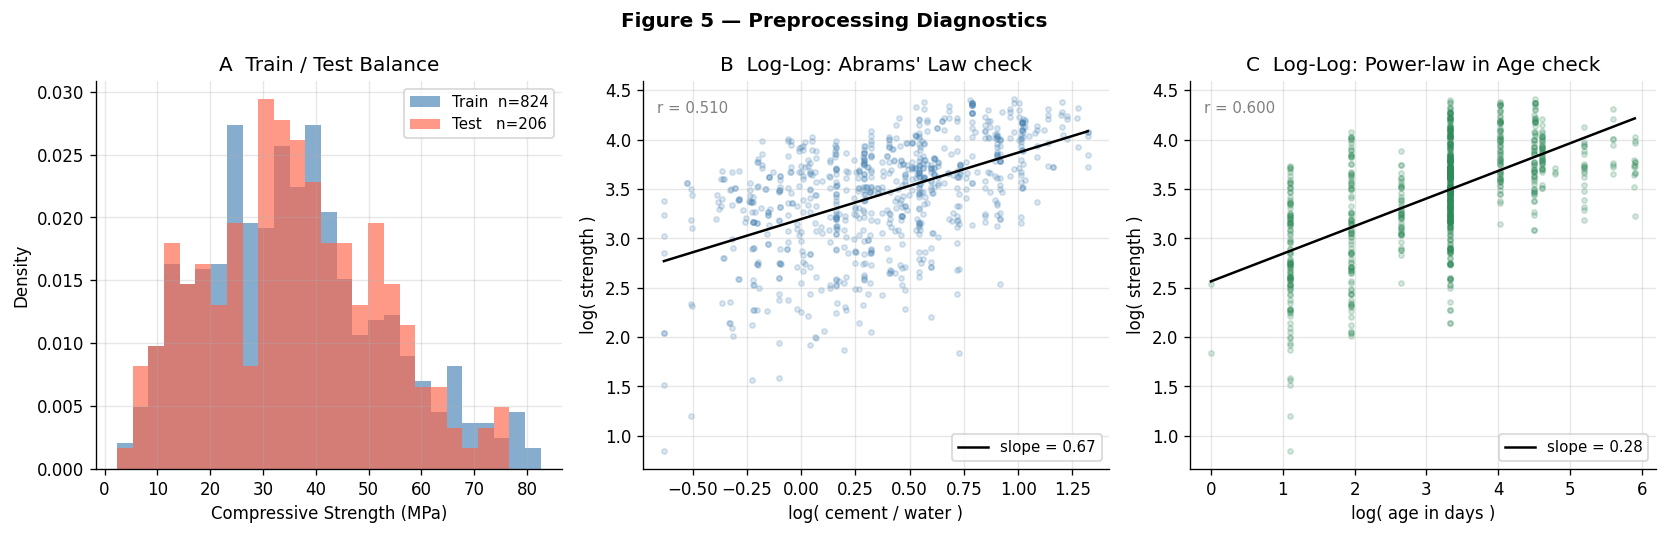

Log-log slopes (inform model_fn initialisation):
  log(strength) ~ 0.673 * log(cement/water)  -> wc exponent ~ 0.67
  log(strength) ~ 0.280 * log(age)           -> age exponent ~ 0.28

These slopes give analytic warm-start estimates for ZZU coeff_to_init.

[9] Proposed nonlinear model_fn skeleton

  Functional form (inspired by Abrams Law + power-law age + additive supplements):

    y = theta[0]
          * (cement / water) ** theta[1]    # Abrams Law core
          * age ** theta[2]                 # power-law cure time
          + theta[3] * slag
          + theta[4] * fly_ash              # additive supplements
          + theta[5] * superplasticizer

  Log-linearised form (used by ZZU screening step):
    log(y_core) = log(theta[0])
                  + theta[1] * log(cement/water)
                  + theta[2] * log(age)

  coeff_to_init will invert OLS coefficients [beta0, beta1, beta2] as:
    theta[0] = exp(beta[0])
    theta[1] = beta[1]   (exponent on c/w)
    theta[2] = beta[

In [4]:
# ================================================================
# BLOCK 2 — Preprocessing
# (df, FEATURES, TARGET, y defined in Block 1)
# ================================================================

# ---- 1. Quality verification ----
print('=' * 60)
print('[1] Quality verification')
print('=' * 60)
print(f'  Rows            : {len(df)}')
print(f'  Missing values  : {df.isnull().sum().sum()}')
n_dup = df.duplicated().sum()
dup_note = '  (same mix design, independent pours — retained)' if n_dup else ''
print(f'  Duplicate rows  : {n_dup}{dup_note}')

# ---- 2. Outlier audit (3-IQR rule, flag only — no removal) ----
print()
print('[2] Outlier audit  (3 x IQR, flag but retain — these are real lab measurements)')
any_outlier = pd.Series(False, index=df.index)
for col in FEATURES + [TARGET]:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 3 * iqr) | (df[col] > q3 + 3 * iqr)
    if mask.sum():
        print(f'  {col:<24}: {mask.sum()} extreme value(s)')
    any_outlier |= mask
print(f'  Rows with >= 1 extreme value: {any_outlier.sum()} / {len(df)}')

# ---- 3. Zero-inflation catalog ----
print()
print('[3] Zero-inflation catalog')
LOG_SAFE      = []   # features that are always > 0 -> safe inside log() / power()
ZERO_INFLATED = []   # features with structural zeros -> additive-only in model_fn
for col in FEATURES:
    n_zero = (df[col] == 0).sum()
    pct    = n_zero / len(df) * 100
    if n_zero == 0:
        LOG_SAFE.append(col)
        print(f'  {col:<24}:     0 zeros  -> log-safe')
    else:
        ZERO_INFLATED.append(col)
        print(f'  {col:<24}: {n_zero:3d} zeros  ({pct:.1f}%)  -> zero-inflated, additive only')

print(f'\n  LOG_SAFE      = {LOG_SAFE}')
print(f'  ZERO_INFLATED = {ZERO_INFLATED}')
print()
print('  Implication for ZZU screening:')
print('    The response (compressive_strength) is always > 0, so log/Box-Cox/YJ on y are valid.')
print('    Log-OLS screening operates on T(y) ~ X*beta; zero-inflated FEATURES do not prevent')
print('    screening but do constrain how they enter model_fn (as additive, not inside log).')

# ---- 4. Feature engineering ----
print()
print('[4] Feature engineering')
df = df.copy()
df['wc_ratio'] = df['water'] / df['cement']
df['binder']   = df['cement'] + df['blast_furnace_slag'] + df['fly_ash']

for feat, formula in [
    ('wc_ratio', 'water / cement          (Abrams Law: primary strength driver)'),
    ('binder',   'cement + slag + fly_ash  (total cementitious content)'),
]:
    r = np.corrcoef(df[feat].values, df[TARGET].values)[0, 1]
    print(f'  + {feat:<10} = {formula}')
    print(f'    r with strength = {r:+.3f}')

# ---- 5. Feature set decision ----
print()
print('[5] Feature set decision')
MODEL_FEATURES = [
    'cement',             # [0] log-safe; appears inside power-law core
    'blast_furnace_slag', # [1] zero-inflated; additive supplement term
    'fly_ash',            # [2] zero-inflated; additive supplement term
    'water',              # [3] log-safe; appears in w/c denominator
    'superplasticizer',   # [4] zero-inflated; additive supplement term
    'coarse_aggregate',   # [5] log-safe; aggregate filler correction
    'fine_aggregate',     # [6] log-safe; aggregate filler correction
    'age',                # [7] log-safe; power-law time term
    'wc_ratio',           # [8] engineered; Abrams Law ratio
]

COL = {name: i for i, name in enumerate(MODEL_FEATURES)}

print(f'  {len(MODEL_FEATURES)} features selected.')
print()
print('  Design rationale:')
print('    cement, water, age  -> always nonzero -> core power-law term: cement^a * age^b / water^c')
print('    slag, fly_ash, SP   -> zero-inflated  -> additive supplement: + d*slag + e*fly_ash + f*SP')
print('    CA, FA              -> aggregate fillers; weakly correlated but kept for completeness')
print('    wc_ratio            -> Abrams Law; highest single-feature correlation with strength')
print()
print('  Column index map (COL) for model_fn:')
for name, idx in COL.items():
    print(f'    COL[\'{ name }\'] = {idx}')

# ---- 6. Train / test split (80 / 20, seed = 42) ----
print()
print('[6] Train/test split  (80/20, seed=42)')
np.random.seed(42)
n_total = len(df)
shuffle = np.random.permutation(n_total)
n_test  = int(round(0.20 * n_total))
test_idx  = shuffle[:n_test]
train_idx = shuffle[n_test:]

X = df[MODEL_FEATURES].values.astype(float)
y_all = df[TARGET].values.astype(float)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}   y_test : {y_test.shape}')
print(f'  Train  -> mean={y_train.mean():.2f} MPa, std={y_train.std():.2f}, '
      f'range=[{y_train.min():.1f}, {y_train.max():.1f}]')
print(f'  Test   -> mean={y_test.mean():.2f} MPa, std={y_test.std():.2f}, '
      f'range=[{y_test.min():.1f}, {y_test.max():.1f}]')

# ---- 7. Feature scale summary ----
print()
print('[7] Feature scales on training set  (relevant for optimizer initialisation)')
print(f'  {"Feature":<24} {"Mean":>10} {"Std":>10} {"Min":>8} {"Max":>8}')
print('  ' + '-' * 64)
for i, col in enumerate(MODEL_FEATURES):
    col_data = X_train[:, i]
    print(f'  {col:<24} {col_data.mean():>10.2f} {col_data.std():>10.2f} '
          f'{col_data.min():>8.2f} {col_data.max():>8.2f}')

print()
print('  Note: features span very different scales (age: 1-365, CA: 801-1145).')
print('  ZZU warm-start initialises near the SSE optimum regardless of scale.')
print('  Cold-start baselines (GD/GN/BFGS) will receive the same unscaled X to')
print('  ensure a fair comparison; their heuristic theta_init is described below.')

# ---- 8. Log-log linearity check (motivates model_fn design) ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Panel A: train vs test response balance
ax = axes[0]
bins = np.linspace(y_all.min(), y_all.max(), 28)
ax.hist(y_train, bins=bins, density=True, alpha=0.65, color='steelblue',
        label=f'Train  n={len(y_train)}')
ax.hist(y_test,  bins=bins, density=True, alpha=0.65, color='tomato',
        label=f'Test   n={len(y_test)}')
ax.set_xlabel('Compressive Strength (MPa)')
ax.set_ylabel('Density')
ax.set_title('A  Train / Test Balance')
ax.legend(fontsize=9)

# Panel B: log-log cement/water vs strength (Abrams Law power-law)
ax = axes[1]
cw_tr = X_train[:, COL['cement']] / X_train[:, COL['water']]
ax.scatter(np.log(cw_tr), np.log(y_train), alpha=0.2, s=10,
           color='steelblue', rasterized=True)
coeff_cw = np.polyfit(np.log(cw_tr), np.log(y_train), 1)
xf = np.linspace(np.log(cw_tr).min(), np.log(cw_tr).max(), 100)
ax.plot(xf, np.polyval(coeff_cw, xf), 'k-', lw=1.5,
        label=f'slope = {coeff_cw[0]:.2f}')
ax.set_xlabel('log( cement / water )')
ax.set_ylabel('log( strength )')
ax.set_title("B  Log-Log: Abrams' Law check")
ax.legend(fontsize=9)
r_cw = np.corrcoef(np.log(cw_tr), np.log(y_train))[0, 1]
ax.text(0.03, 0.95, f'r = {r_cw:.3f}', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='gray')

# Panel C: log-log age vs strength (power-law in time)
ax = axes[2]
ages_tr = X_train[:, COL['age']]
ax.scatter(np.log(ages_tr), np.log(y_train), alpha=0.2, s=10,
           color='seagreen', rasterized=True)
coeff_age = np.polyfit(np.log(ages_tr), np.log(y_train), 1)
xf2 = np.linspace(np.log(ages_tr).min(), np.log(ages_tr).max(), 100)
ax.plot(xf2, np.polyval(coeff_age, xf2), 'k-', lw=1.5,
        label=f'slope = {coeff_age[0]:.2f}')
ax.set_xlabel('log( age in days )')
ax.set_ylabel('log( strength )')
ax.set_title('C  Log-Log: Power-law in Age check')
ax.legend(fontsize=9)
r_age = np.corrcoef(np.log(ages_tr), np.log(y_train))[0, 1]
ax.text(0.03, 0.95, f'r = {r_age:.3f}', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='gray')

fig.suptitle('Figure 5 — Preprocessing Diagnostics', fontweight='bold')
fig.tight_layout()
plt.show()

print('Log-log slopes (inform model_fn initialisation):')
print(f'  log(strength) ~ {coeff_cw[0]:.3f} * log(cement/water)  -> wc exponent ~ {coeff_cw[0]:.2f}')
print(f'  log(strength) ~ {coeff_age[0]:.3f} * log(age)           -> age exponent ~ {coeff_age[0]:.2f}')
print()
print('These slopes give analytic warm-start estimates for ZZU coeff_to_init.')

# ---- 9. Proposed model_fn skeleton (for reference in next notebook) ----
print()
print('[9] Proposed nonlinear model_fn skeleton')
print()
print('  Functional form (inspired by Abrams Law + power-law age + additive supplements):')
print()
print('    y = theta[0]')
print('          * (cement / water) ** theta[1]    # Abrams Law core')
print('          * age ** theta[2]                 # power-law cure time')
print('          + theta[3] * slag')
print('          + theta[4] * fly_ash              # additive supplements')
print('          + theta[5] * superplasticizer')
print()
print('  Log-linearised form (used by ZZU screening step):')
print('    log(y_core) = log(theta[0])')
print('                  + theta[1] * log(cement/water)')
print('                  + theta[2] * log(age)')
print()
print('  coeff_to_init will invert OLS coefficients [beta0, beta1, beta2] as:')
print('    theta[0] = exp(beta[0])')
print('    theta[1] = beta[1]   (exponent on c/w)')
print('    theta[2] = beta[2]   (exponent on age)')
print('    theta[3..5] = 0.1    (small positive starting values for additive terms)')

# ---- 10. Save artifacts ----
np.savez(
    'concrete_split.npz',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    col_names=np.array(MODEL_FEATURES),
    log_safe=np.array(LOG_SAFE),
    zero_inflated=np.array(ZERO_INFLATED),
    cw_slope=np.array([coeff_cw[0]]),
    age_slope=np.array([coeff_age[0]]),
)
print()
print('Saved concrete_split.npz')
print('  Arrays : X_train, X_test, y_train, y_test')
print('  Metadata: col_names, log_safe, zero_inflated, cw_slope, age_slope')
print()
print('Load in next notebook with:')
print("  data = np.load('concrete_split.npz', allow_pickle=True)")
print("  X_train = data['X_train']   # shape", X_train.shape)
print("  COL     = {name: i for i, name in enumerate(data['col_names'])}")
print()
print('Preprocessing complete.')

---
## Block 3 — ZZU and Baseline Comparison

Runs the full ZZU workflow and five competing methods on the preprocessed concrete dataset.

**Methods compared:**

| Method | Family |
|---|---|
| `identity_ols` | Linearized OLS (plain OLS on log-transformed X features, no y-transform) |
| `log_smear` | Linearized OLS — ZZU Step 1 alone; best single-transform baseline |
| `boxcox_smear` | Linearized OLS — Box-Cox λ selected by profile likelihood |
| `bfgs_cold` | Nonlinear BFGS with heuristic Abrams'-Law init (no screening) |
| `gn_cold` | Nonlinear Gauss-Newton with same cold init |
| `zzu_bfgs` | **ZZU hybrid** — screening → warm start → BFGS refinement |

**Evaluation:** 10 random 80/20 seeds, test RMSE/R² reported as mean ± std.

X_zzu shape train: (824, 5) test: (206, 5)
Columns: [log(c/w), log(age), slag, fly_ash, SP]

PART A — Single-split walkthrough
ZZU-BFGS
Screening table:
        name  val_rmse
0  log_smear  9.392487
best_transform : log_smear
theta_init     : [1.7719 1.0075 0.2976 0.0028 0.0025 0.0015]
theta_final    : [ 2.1747  0.8779  0.2193  0.0025  0.0024 -0.0006]
converged      : True
n_iter         : 13
test RMSE      : 7.4050 MPa
test R2        : 0.7872
fit time       : 21.7 ms

Cold nonlinear baselines
BFGS cold RMSE : 36.7058 MPa
BFGS cold R2   : -4.2286
BFGS cold time : 24.9 ms
GN cold RMSE   : 7.4050 MPa
GN cold R2     : 0.7872
GN cold time   : 5.6 ms

Linearized OLS baselines
identity_ols   RMSE = 6.9012 MPa, R2 = 0.8152, time = 0.3 ms
log_smear      RMSE = 8.5588 MPa, R2 = 0.7157, time = 0.2 ms
boxcox_smear   RMSE = 6.9755 MPa, R2 = 0.8112, time = 30.8 ms

PART B — Multi-seed comparison


,method,family,rmse_mean,rmse_std,r2_mean,r2_std,fit_ms_mean,converged_rate
1,boxcox_smear,Linearized OLS,7.249661,0.326123,0.803151,0.018677,35.34552,1.0
3,identity_ols,Linearized OLS,7.253777,0.349079,0.803244,0.015411,0.33071,1.0
5,zzu_bfgs,ZZU hybrid,7.602272,0.340319,0.783743,0.017860,22.67570,1.0
2,gn_cold,Nonlinear cold,7.602272,0.340319,0.783743,0.017860,5.61849,1.0
4,log_smear,Linearized OLS,8.742916,0.514152,0.712751,0.040969,0.20196,1.0
0,bfgs_cold,Nonlinear cold,35.674441,0.750463,-3.758286,0.219648,24.17507,1.0



Best method by mean RMSE:
method              boxcox_smear
family            Linearized OLS
rmse_mean               7.249661
rmse_std                0.326123
r2_mean                 0.803151
r2_std                  0.018677
fit_ms_mean             35.34552
converged_rate               1.0
Name: 1, dtype: object


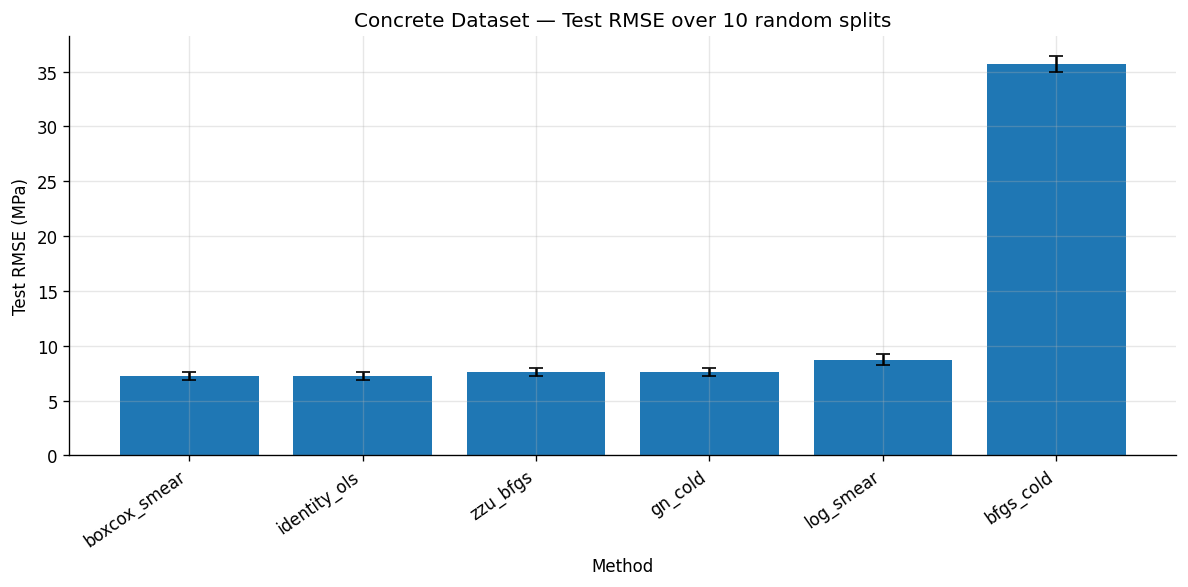

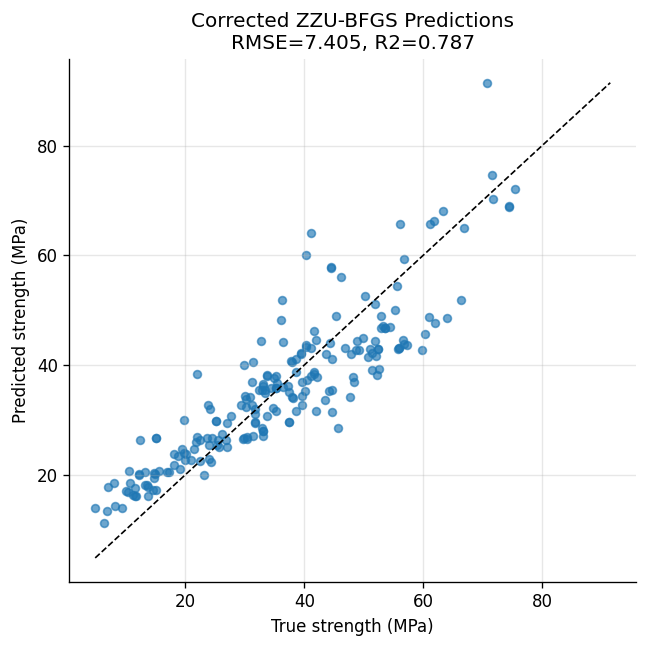

In [6]:
# ================================================================
# BLOCK 3 — ZZU and Baseline Comparison on Concrete Dataset
# ================================================================
import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
import transformation_algorithms as ta

# ---- Load preprocessed split ----
_d = np.load('concrete_split.npz', allow_pickle=True)
X_tr_raw = _d['X_train']
X_te_raw = _d['X_test']
y_tr = _d['y_train']
y_te = _d['y_test']

df_full = pd.read_csv('concrete.csv')
df_full['wc_ratio'] = df_full['water'] / df_full['cement']

RAW_COLS = [
    'cement', 'blast_furnace_slag', 'fly_ash', 'water',
    'superplasticizer', 'coarse_aggregate', 'fine_aggregate',
    'age', 'wc_ratio'
]
RCOL = {c: i for i, c in enumerate(RAW_COLS)}

X_all_raw = df_full[RAW_COLS].values.astype(float)
y_all = df_full['compressive_strength'].values.astype(float)

# ================================================================
# Feature construction
# X_zzu columns:
# [0] log(cement/water)
# [1] log(age)
# [2] slag
# [3] fly_ash
# [4] superplasticizer
# ================================================================
def make_Xzzu(X_raw):
    cw = X_raw[:, RCOL['cement']] / X_raw[:, RCOL['water']]
    age = X_raw[:, RCOL['age']]
    return np.column_stack([
        np.log(cw),
        np.log(age),
        X_raw[:, RCOL['blast_furnace_slag']],
        X_raw[:, RCOL['fly_ash']],
        X_raw[:, RCOL['superplasticizer']],
    ])

X_tr = make_Xzzu(X_tr_raw)
X_te = make_Xzzu(X_te_raw)

print(f'X_zzu shape train: {X_tr.shape} test: {X_te.shape}')
print('Columns: [log(c/w), log(age), slag, fly_ash, SP]')

# ================================================================
# Corrected nonlinear model
#
# This matches the log-screening model exactly:
# log(y) = theta0
#        + theta1 * log(c/w)
#        + theta2 * log(age)
#        + theta3 * slag
#        + theta4 * fly_ash
#        + theta5 * SP
# ================================================================
def model_fn(X, theta):
    eta = (
        theta[0]
        + theta[1] * X[:, 0]
        + theta[2] * X[:, 1]
        + theta[3] * X[:, 2]
        + theta[4] * X[:, 3]
        + theta[5] * X[:, 4]
    )
    eta = np.clip(eta, -20, 20)
    return np.exp(eta)

# Correct inverse of log-linear OLS coefficients.
# Since X already contains log(c/w), log(age), slag, fly_ash, SP,
# beta_ directly corresponds to theta.
def coeff_to_init(best_tols_model):
    return best_tols_model.beta_.copy()

# Cold init for nonlinear baselines, without ZZU screening
def make_theta_cold(y_train):
    return np.array([
        np.log(np.median(y_train)),
        0.50,
        0.15,
        0.001,
        0.001,
        0.010,
    ])

# IMPORTANT:
# ZZU screening must only include transforms compatible with coeff_to_init.
# Do NOT include identity/sqrt/Box-Cox/YJ unless coeff_to_init handles each case.
def make_zzu_suite():
    return {
        'log_smear': ta.TransformedOLS(transform='log', use_smearing=True),
    }

def make_baseline_suite():
    return {
        'identity_ols': ta.TransformedOLS(transform='identity', use_smearing=False),
        'log_smear': ta.TransformedOLS(transform='log', use_smearing=True),
        'boxcox_smear': ta.TransformedOLS(transform='boxcox', use_smearing=True),
    }

# ================================================================
# Single split walkthrough
# ================================================================
print()
print('=' * 65)
print('PART A — Single-split walkthrough')
print('=' * 65)

theta_cold = make_theta_cold(y_tr)

t0 = time.perf_counter()
zzu = ta.ZZUTransformRegressor(
    model_fn=model_fn,
    coeff_to_init=coeff_to_init,
    nonlinear_method='bfgs',
    transformations=make_zzu_suite(),
    val_fraction=0.2,
    seed=0,
).fit(X_tr, y_tr)
zzu_ms = (time.perf_counter() - t0) * 1000

zzu_pred = zzu.predict(X_te, use_smearing=False)
zzu_m = ta.regression_metrics(y_te, zzu_pred)

print('ZZU-BFGS')
print('Screening table:')
print(zzu.screening_table_[['name', 'val_rmse']])
print(f'best_transform : {zzu.best_transform_name_}')
print(f'theta_init     : {np.round(zzu.theta_init_used_, 4)}')
print(f'theta_final    : {np.round(zzu.nonlinear_regressor_.theta_, 4)}')
print(f'converged      : {zzu.nonlinear_regressor_.converged_}')
print(f'n_iter         : {zzu.nonlinear_regressor_.n_iter_}')
print(f'test RMSE      : {zzu_m["rmse"]:.4f} MPa')
print(f'test R2        : {zzu_m["r2"]:.4f}')
print(f'fit time       : {zzu_ms:.1f} ms')

print()
print('Cold nonlinear baselines')

t0 = time.perf_counter()
bfgs_c = ta.BFGSRegressor(model_fn=model_fn).fit(X_tr, y_tr, theta_cold)
bfgs_ms = (time.perf_counter() - t0) * 1000
bfgs_m = ta.regression_metrics(y_te, bfgs_c.predict(X_te))

print(f'BFGS cold RMSE : {bfgs_m["rmse"]:.4f} MPa')
print(f'BFGS cold R2   : {bfgs_m["r2"]:.4f}')
print(f'BFGS cold time : {bfgs_ms:.1f} ms')

t0 = time.perf_counter()
gn_c = ta.GaussNewtonRegressor(model_fn=model_fn).fit(X_tr, y_tr, theta_cold)
gn_ms = (time.perf_counter() - t0) * 1000
gn_m = ta.regression_metrics(y_te, gn_c.predict(X_te))

print(f'GN cold RMSE   : {gn_m["rmse"]:.4f} MPa')
print(f'GN cold R2     : {gn_m["r2"]:.4f}')
print(f'GN cold time   : {gn_ms:.1f} ms')

print()
print('Linearized OLS baselines')

for name, reg in make_baseline_suite().items():
    t0 = time.perf_counter()
    reg.fit(X_tr, y_tr)
    ms = (time.perf_counter() - t0) * 1000
    pred = reg.predict(X_te)
    m = ta.regression_metrics(y_te, pred)
    print(f'{name:<14} RMSE = {m["rmse"]:.4f} MPa, R2 = {m["r2"]:.4f}, time = {ms:.1f} ms')

# ================================================================
# Multi-seed comparison
# ================================================================
def evaluate_one_seed(seed):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y_all))
    n_test = int(round(0.20 * len(y_all)))

    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    Xtr_raw = X_all_raw[train_idx]
    Xte_raw = X_all_raw[test_idx]
    ytr = y_all[train_idx]
    yte = y_all[test_idx]

    Xtr = make_Xzzu(Xtr_raw)
    Xte = make_Xzzu(Xte_raw)
    theta0 = make_theta_cold(ytr)

    rows = []

    for name, reg in make_baseline_suite().items():
        t0 = time.perf_counter()
        reg.fit(Xtr, ytr)
        fit_ms = (time.perf_counter() - t0) * 1000
        pred = reg.predict(Xte)
        m = ta.regression_metrics(yte, pred)

        rows.append({
            'seed': seed,
            'method': name,
            'family': 'Linearized OLS',
            'rmse': m['rmse'],
            'r2': m['r2'],
            'fit_ms': fit_ms,
            'converged': True,
        })

    t0 = time.perf_counter()
    bfgs = ta.BFGSRegressor(model_fn=model_fn).fit(Xtr, ytr, theta0)
    fit_ms = (time.perf_counter() - t0) * 1000
    pred = bfgs.predict(Xte)
    m = ta.regression_metrics(yte, pred)

    rows.append({
        'seed': seed,
        'method': 'bfgs_cold',
        'family': 'Nonlinear cold',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': fit_ms,
        'converged': bfgs.converged_,
    })

    t0 = time.perf_counter()
    gn = ta.GaussNewtonRegressor(model_fn=model_fn).fit(Xtr, ytr, theta0)
    fit_ms = (time.perf_counter() - t0) * 1000
    pred = gn.predict(Xte)
    m = ta.regression_metrics(yte, pred)

    rows.append({
        'seed': seed,
        'method': 'gn_cold',
        'family': 'Nonlinear cold',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': fit_ms,
        'converged': gn.converged_,
    })

    t0 = time.perf_counter()
    zzu = ta.ZZUTransformRegressor(
        model_fn=model_fn,
        coeff_to_init=coeff_to_init,
        nonlinear_method='bfgs',
        transformations=make_zzu_suite(),
        val_fraction=0.2,
        seed=seed,
    ).fit(Xtr, ytr)
    fit_ms = (time.perf_counter() - t0) * 1000
    pred = zzu.predict(Xte, use_smearing=False)
    m = ta.regression_metrics(yte, pred)

    rows.append({
        'seed': seed,
        'method': 'zzu_bfgs',
        'family': 'ZZU hybrid',
        'rmse': m['rmse'],
        'r2': m['r2'],
        'fit_ms': fit_ms,
        'converged': zzu.nonlinear_regressor_.converged_,
        'best_transform': zzu.best_transform_name_,
    })

    return rows

print()
print('=' * 65)
print('PART B — Multi-seed comparison')
print('=' * 65)

all_rows = []
for seed in range(10):
    all_rows.extend(evaluate_one_seed(seed))

results = pd.DataFrame(all_rows)

summary = (
    results
    .groupby(['method', 'family'])
    .agg(
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        r2_mean=('r2', 'mean'),
        r2_std=('r2', 'std'),
        fit_ms_mean=('fit_ms', 'mean'),
        converged_rate=('converged', 'mean'),
    )
    .reset_index()
    .sort_values('rmse_mean')
)

display(summary)

print()
print('Best method by mean RMSE:')
print(summary.iloc[0])

# ================================================================
# Plot RMSE comparison
# ================================================================
plt.figure(figsize=(10, 5))
plt.bar(summary['method'], summary['rmse_mean'], yerr=summary['rmse_std'], capsize=4)
plt.ylabel('Test RMSE (MPa)')
plt.xlabel('Method')
plt.title('Concrete Dataset — Test RMSE over 10 random splits')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# ================================================================
# Prediction scatter for corrected ZZU on seed=42 split
# ================================================================
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_te, zzu_pred, alpha=0.65, s=22)
lo = min(y_te.min(), zzu_pred.min())
hi = max(y_te.max(), zzu_pred.max())
plt.plot([lo, hi], [lo, hi], 'k--', lw=1)
plt.xlabel('True strength (MPa)')
plt.ylabel('Predicted strength (MPa)')
plt.title(f'Corrected ZZU-BFGS Predictions\nRMSE={zzu_m["rmse"]:.3f}, R2={zzu_m["r2"]:.3f}')
plt.tight_layout()
plt.show()